# LUMINA - Breast Cancer Classification

--- 1. IMPORTS ---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from joblib import dump

--- 2. LOAD & EXPLORE ---

In [2]:
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()
data_frame = pd.DataFrame(
  breast_cancer_dataset.data,
  columns=breast_cancer_dataset.feature_names
)
data_frame['label'] = breast_cancer_dataset.target

print(data_frame.shape)
print(data_frame.head())
print(data_frame.tail())
print(data_frame.info())
print(data_frame.isnull().sum())
print(data_frame.describe())
print(data_frame['label'].value_counts())
print(data_frame.groupby('label').mean())

(569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0   

--- 3. SEPARATE FEATURES & TARGET ---

In [3]:
X = data_frame.drop(columns='label')
Y = data_frame['label']

--- 4. TRAIN/TEST SPLIT ---

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(
  X, Y, test_size=0.2, random_state=2
)
print('X shape:', X.shape)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X shape: (569, 30)
X_train shape: (455, 30)
X_test shape: (114, 30)


--- 5. STANDARDIZE ---

In [5]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

--- 6. BUILD NEURAL NETWORK ---

In [6]:
model = keras.Sequential([
  keras.layers.Flatten(input_shape=(30,)),
  keras.layers.Dense(20, activation='relu'),
  keras.layers.Dense(2, activation='softmax')
])

model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

history = model.fit(
  X_train_std, Y_train,
  validation_split=0.1,
  epochs=10
)

c:\Users\Mahima\Desktop\breast_cancer_detection\lumina\backend\train_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7848 - loss: 0.4808 - val_accuracy: 0.9130 - val_loss: 0.3694
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8631 - loss: 0.3441 - val_accuracy: 0.9348 - val_loss: 0.2719
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8924 - loss: 0.2710 - val_accuracy: 0.9348 - val_loss: 0.2182
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9144 - loss: 0.2274 - val_accuracy: 0.9565 - val_loss: 0.1861
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9413 - loss: 0.1986 - val_accuracy: 0.9565 - val_loss: 0.1645
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9438 - loss: 0.1777 - val_accuracy: 0.9565 - val_loss: 0.1489
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9487 - loss: 0.1615 - val_accuracy: 0.9565 - val_loss: 0.1366
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9560 - loss: 0.1483 - val_accuracy: 0.9565 - val_loss

--- 7. VISUALIZE TRAINING ---

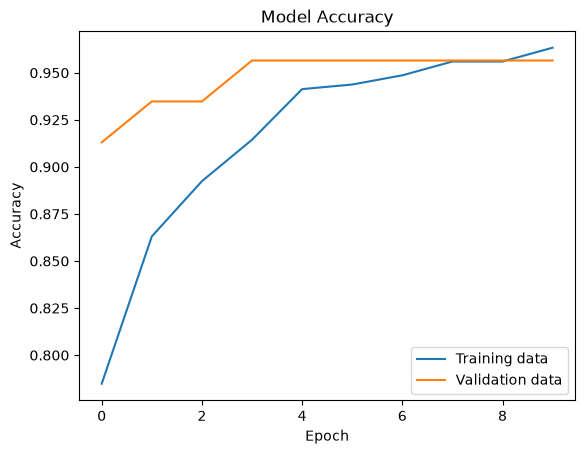

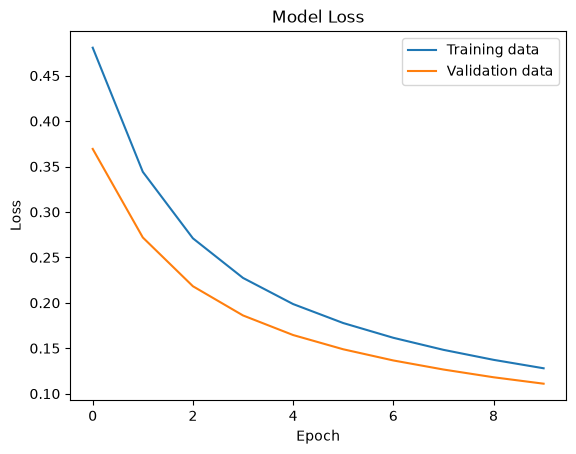

In [7]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training data', 'Validation data'], loc='lower right')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training data', 'Validation data'], loc='upper right')
plt.show()

--- 8. EVALUATE ---

In [8]:
loss, accuracy = model.evaluate(X_test_std, Y_test)
print(f"Test Accuracy: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9561 - loss: 0.1248
Test Accuracy: 0.9561


--- 9. PREDICTIONS ---

In [9]:
Y_pred = model.predict(X_test_std)
Y_pred_labels = [np.argmax(i) for i in Y_pred]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


--- 10. TEST THE PREDICTIVE SYSTEM ---

In [10]:
input_data = (
  11.76, 21.6,  74.72, 427.9,  0.08637, 0.04966,
  0.01657, 0.01115, 0.1495, 0.05888,
  0.4062, 1.21,  2.635, 28.47, 0.005857, 0.009758,
  0.01168, 0.007445, 0.02406, 0.001769,
  12.98, 25.72, 82.98, 516.5, 0.1085, 0.08615,
  0.05523, 0.03715, 0.2433, 0.06563
)

input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)
input_data_std = scaler.transform(input_data_reshaped)

prediction = model.predict(input_data_std)
prediction_label = [np.argmax(prediction)]

if prediction_label[0] == 0:
  print('The tumor is Malignant')
else:
  print('The tumor is Benign')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
The tumor is Benign


c:\Users\Mahima\Desktop\breast_cancer_detection\lumina\backend\train_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


--- 11. EXPORT ---

In [11]:
# Save Keras model
model.save('breast_cancer_nn.keras')

# Save scaler
dump(scaler, 'scaler.pkl')

# Save feature names in exact order for Flask validation
import json
feature_names = list(breast_cancer_dataset.feature_names)
with open('feature_names.json', 'w') as f:
  json.dump(feature_names, f)

# Save training set means for the 20 non-user-input features
# (SE and worst groups — filled automatically by the backend
# when user only provides the 10 mean features via the form)
import pandas as pd
X_train_df = pd.DataFrame(X_train_std,
                           columns=breast_cancer_dataset.feature_names)
se_worst_means = {
  col: float(X_train_df[col].mean())
  for col in breast_cancer_dataset.feature_names[10:]  # indices 10–29
}
with open('se_worst_means.json', 'w') as f:
  json.dump(se_worst_means, f)

print("Exported: breast_cancer_nn.keras, scaler.pkl,")
print("          feature_names.json, se_worst_means.json")

Exported: breast_cancer_nn.keras, scaler.pkl,
          feature_names.json, se_worst_means.json
